In [80]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from sklearn.metrics import accuracy_score
from pathlib import Path
from collections import OrderedDict

%matplotlib inline
matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'figure.dpi': 110,
    'savefig.bbox': 'tight',
})

# ─── paths ────────────────────────────────────────────────────────────────────
DATA_ROOT = Path('/vol/bitbucket/gk225/POC_DDM_datasets/LAB_DDM_paper')
REG_SENTINEL = -9999.0

# ─── dataset ordering + display labels ───────────────────────────────────────
DATASETS_ORDER = [
    '01_ACA_qdPCR',
    '02_AMCA_qdLAMP',
    '03_AMCA_qdPCR',
    '07_ACA_qdPCR_conc_filtered',
    '08_AMCA_qdPCR_conc_filtered',
    '09_Area_Conc',
    '10_Range_Conc',
]

DS_LABELS = {
    '01_ACA_qdPCR':                  'ACA qdPCR',
    '03_AMCA_qdPCR':                 'AMCA qdPCR',
    '07_ACA_qdPCR_conc_filtered':    'ACA qdPCR (conc-filt)',
    '08_AMCA_qdPCR_conc_filtered':   'AMCA qdPCR (conc-filt)',
    '09_Area_Conc':                  'Area+Conc',
    '10_Range_Conc':                 'Range+Conc',
    '02_AMCA_qdLAMP':                'AMCA qdLAMP',
}

DS_LABELS = {
    '01_ACA_qdPCR':                  '01_ACA_qdPCR',
    '03_AMCA_qdPCR':                 '03_AMCA_qdPCR',
    '07_ACA_qdPCR_conc_filtered':    '07_ACA_qdPCR_conc_filtered',
    '08_AMCA_qdPCR_conc_filtered':   '08_AMCA_qdPCR_conc_filtered',
    '09_Area_Conc':                  '09_Area_Conc',
    '10_Range_Conc':                 '10_Range_Conc',
    '02_AMCA_qdLAMP':                '02_AMCA_qdLAMP',
}


# ─── model families ───────────────────────────────────────────────────────────
CLS_KEYS  = ['cgd_rc_poc', 'cgd_rc_poc_sc1', 'cgd_rc_poc_sc2', 'cgd_rc_poc_sc3']
MTL_KEYS  = ['mtl_cgd_rc_poc', 'mtl_cgd_rc_poc_sc1', 'mtl_cgd_rc_poc_sc2', 'mtl_cgd_rc_poc_sc3']
RCFD_KEYS = ['gru_rcfd_cgd_rc_poc', 'gru_rcfd_cgd_rc_poc_sc1', 'gru_rcfd_cgd_rc_poc_sc2', 'gru_rcfd_cgd_rc_poc_sc3']
CCFD_KEYS = ['gru_ccfd_cgd_rc_poc', 'gru_ccfd_cgd_rc_poc_sc1', 'gru_ccfd_cgd_rc_poc_sc2', 'gru_ccfd_cgd_rc_poc_sc3']

FAMILIES = OrderedDict([
    ('CGD',      CLS_KEYS),
    ('MTL',      MTL_KEYS),
    ('RCFD',     RCFD_KEYS),
    ('CCFD-POC', CCFD_KEYS),
])

FAMILY_LABEL = {
    'CGD':      'CGD (pure cls)',
    'MTL':      'MTL (joint cls+reg)',
    'RCFD':     'RCFD (reg→FiLM→cls)',
    'CCFD-POC': 'CCFD-POC (frozen cls→FiLM→reg)',
}

# dark→light per SC level (SC0 darkest, SC3 lightest)
FCOLORS = {
    'CGD':      ['#0D47A1', '#1565C0', '#1E88E5', '#64B5F6'],
    'MTL':      ['#1B5E20', '#2E7D32', '#43A047', '#81C784'],
    'RCFD':     ['#BF360C', '#E64A19', '#FF7043', '#FFAB91'],
    'CCFD-POC': ['#4A148C', '#7B1FA2', '#AB47BC', '#CE93D8'],
}

FAMILY_REPR_COLOR = {f: cs[1] for f, cs in FCOLORS.items()}  # SC1 color as representative

SC_LABELS = ['SC0', 'SC1', 'SC2', 'SC3']
print('Setup complete.')

Setup complete.


In [66]:
# ─── load all rc_poc results ──────────────────────────────────────────────────

def compute_rmse(reg_trues_list, reg_preds_list):
    rmses = []
    for rt, rp in zip(reg_trues_list, reg_preds_list):
        rt, rp = np.asarray(rt, float), np.asarray(rp, float)
        v = (rt != REG_SENTINEL) & np.isfinite(rt) & np.isfinite(rp)
        if v.sum() >= 2:
            rmses.append(np.sqrt(np.mean((rt[v] - rp[v]) ** 2)))
    return np.mean(rmses) if rmses else np.nan

def get_conc_mean(res):
    """Mean concentration across all folds (for normalisation)."""
    for key in res:
        if key.startswith('y_reg_trues_'):
            all_rt = np.concatenate([np.asarray(rt, float) for rt in res[key]])
            valid  = all_rt[(all_rt != REG_SENTINEL) & np.isfinite(all_rt)]
            return valid.mean() if len(valid) else np.nan
    return np.nan

# Raw accuracy (%) and RMSE per dataset × model
cls_data  = {}   # {ds_id: {model_key: accuracy_pct}}
reg_data  = {}   # {ds_id: {model_key: rmse}}
conc_mean = {}   # {ds_id: mean_concentration}  — for normalisation

for ds_id in DATASETS_ORDER:
    fp = DATA_ROOT / ds_id / 'rc_poc' / 'rc_poc_results.joblib'
    if not fp.exists():
        print(f'  [MISSING] {ds_id}')
        continue
    d = joblib.load(fp)

    res = None
    for _, mode_dict in d.items():
        for _, res_dict in mode_dict.items():
            for _, r in res_dict.items():
                if isinstance(r, dict) and 'y_trues_' in r:
                    res = r
                    break
    if res is None:
        print(f'  [NO DATA] {ds_id}'); continue

    y_trues = res['y_trues_']
    cls_data[ds_id]  = {}
    reg_data[ds_id]  = {}
    conc_mean[ds_id] = get_conc_mean(res)

    for family, keys in FAMILIES.items():
        for key in keys:
            pk  = f'y_preds_AC_{key}_'
            rpk = f'y_reg_preds_{key}_'
            rtk = f'y_reg_trues_{key}_'

            if pk in res:
                accs = [accuracy_score(yt, yp) for yt, yp in zip(y_trues, res[pk])]
                cls_data[ds_id][key] = np.mean(accs) * 100

            if rpk in res and rtk in res:
                reg_data[ds_id][key] = compute_rmse(res[rtk], res[rpk])

# Summary DataFrame for convenience
rows = []
for ds_id in DATASETS_ORDER:
    for family, keys in FAMILIES.items():
        for sc_idx, key in enumerate(keys):
            acc  = cls_data.get(ds_id, {}).get(key, np.nan)
            rmse = reg_data.get(ds_id, {}).get(key, np.nan)
            cmean = conc_mean.get(ds_id, np.nan)
            rows.append(dict(
                dataset=ds_id, ds_label=DS_LABELS[ds_id],
                family=family, model_key=key, sc=sc_idx,
                accuracy=acc, rmse=rmse,
                rmse_pct=rmse / cmean * 100 if (not np.isnan(rmse) and cmean > 0) else np.nan,
            ))

df = pd.DataFrame(rows)
print(f'Loaded {len(df)} rows × {len(DATASETS_ORDER)} datasets')
df.groupby('family')[['accuracy', 'rmse_pct']].mean().round(2)

Loaded 112 rows × 7 datasets


,accuracy,rmse_pct
family,,
CCFD-POC,NaN,49.11
CGD,95.08,NaN
MTL,94.97,39.40
RCFD,94.87,41.31


In [67]:
# ─── Master DataFrame — all raw results ───────────────────────────────────────
CLS_KEY_SET = set(CLS_KEYS)
REG_KEY_SET = set(MTL_KEYS + RCFD_KEYS + CCFD_KEYS)

rows_raw = []
for ds_id in DATASETS_ORDER:
    cmean = conc_mean.get(ds_id, np.nan)
    for family, keys in FAMILIES.items():
        for sc_idx, key in enumerate(keys):
            acc  = cls_data.get(ds_id, {}).get(key, np.nan)
            rmse = reg_data.get(ds_id, {}).get(key, np.nan)
            rows_raw.append({
                'dataset':      DS_LABELS[ds_id],
                'dataset_id':   ds_id,
                'family':       family,
                'model_key':    key,
                'sc':           sc_idx,
                'has_cls':      key not in set(CCFD_KEYS),
                'has_reg':      key in REG_KEY_SET,
                'accuracy_pct': acc,
                'rmse':         rmse,
                'rmse_pct':     rmse / cmean * 100 if (not np.isnan(rmse) and cmean > 0) else np.nan,
                'conc_mean':    cmean,
            })

raw_df = pd.DataFrame(rows_raw)[[
    'dataset', 'family', 'sc', 'model_key',
    'accuracy_pct', 'rmse', 'rmse_pct',
    'has_cls', 'has_reg', 'conc_mean', 'dataset_id',
]]

print(f'Shape: {raw_df.shape}  ({len(DATASETS_ORDER)} datasets × 16 models)')
print(f'NaN accuracy (CCFD-POC, no cls): {raw_df["accuracy_pct"].isna().sum()}')
print(f'NaN rmse (CGD, no reg): {raw_df["rmse"].isna().sum()}')
print()
with pd.option_context('display.max_rows', 20, 'display.float_format', '{:.3f}'.format):
    display(raw_df)


Shape: (112, 11)  (7 datasets × 16 models)
NaN accuracy (CCFD-POC, no cls): 28
NaN rmse (CGD, no reg): 28



,dataset,family,sc,model_key,accuracy_pct,rmse,rmse_pct,has_cls,has_reg,conc_mean,dataset_id
0,ACA qdPCR,CGD,0,cgd_rc_poc,99.382,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
1,ACA qdPCR,CGD,1,cgd_rc_poc_sc1,99.320,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
2,ACA qdPCR,CGD,2,cgd_rc_poc_sc2,99.444,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
3,ACA qdPCR,CGD,3,cgd_rc_poc_sc3,99.506,NaN,NaN,True,False,445825.093,01_ACA_qdPCR
4,ACA qdPCR,MTL,0,mtl_cgd_rc_poc,99.506,158776.224,35.614,True,True,445825.093,01_ACA_qdPCR
...,...,...,...,...,...,...,...,...,...,...,...
107,Range+Conc,RCFD,3,gru_rcfd_cgd_rc_poc_sc3,90.476,279294.469,76.402,True,True,365558.442,10_Range_Conc
108,Range+Conc,CCFD-POC,0,gru_ccfd_cgd_rc_poc,NaN,320701.953,87.729,False,True,365558.442,10_Range_Conc
109,Range+Conc,CCFD-POC,1,gru_ccfd_cgd_rc_poc_sc1,NaN,318911.083,87.239,False,True,365558.442,10_Range_Conc
110,Range+Conc,CCFD-POC,2,gru_ccfd_cgd_rc_poc_sc2,NaN,282503.255,77.280,False,True,365558.442,10_Range_Conc


In [68]:
# ─── helpers for grouped horizontal barchart ──────────────────────────────────

def draw_grouped_hbar(ax, data_dict, ds_order, ds_labels,
                      family_order, families, fcolors,
                      bar_h=0.55, family_gap=0.5, ds_gap=1.2):
    """
    Draws a grouped horizontal bar chart.
    Returns (ds_centers, y_max) for axis formatting.

    data_dict : {ds_id: {model_key: value}}
    family_order: list of family names in desired top→bottom order
    """
    y = 0.0
    ds_centers = {}
    bar_positions = []  # list of (y_pos, val, color, ds_id, key)

    for ds_id in reversed(ds_order):  # reversed → first dataset on top
        ds_start = y
        for f_idx, fname in enumerate(family_order):
            if f_idx > 0:
                y += family_gap
            for sc_idx, key in enumerate(families[fname]):
                val = data_dict.get(ds_id, {}).get(key, np.nan)
                color = fcolors[fname][sc_idx]
                bar_positions.append((y, val, color, ds_id, key))
                y += bar_h
        ds_centers[ds_id] = (ds_start + y) / 2
        y += ds_gap

    y_max = y

    for y_pos, val, color, ds_id, key in bar_positions:
        if np.isnan(val):
            continue
        ax.barh(y_pos, val, height=bar_h * 0.9, color=color,
                align='edge', edgecolor='white', linewidth=0.3)

    return ds_centers, y_max


def format_ds_yaxis(ax, ds_centers, ds_order, ds_labels, y_max):
    ax.set_yticks([ds_centers[d] for d in ds_order if d in ds_centers])
    ax.set_yticklabels([ds_labels[d] for d in ds_order if d in ds_centers], fontsize=11)
    ax.set_ylim(-0.5, y_max)

    # Horizontal separator lines between dataset groups
    centers = sorted(ds_centers.values())
    for i in range(1, len(centers)):
        mid = (centers[i-1] + centers[i]) / 2
        ax.axhline(mid, color='#BDBDBD', linewidth=0.8, linestyle='--')


def make_legend(ax, family_order, families, fcolors, family_label, ncol=1, loc='lower right'):
    handles = []
    for fname in family_order:
        handles.append(mpatches.Patch(color='none', label=f'── {family_label[fname]} ──'))
        for sc_idx, sc_lbl in enumerate(SC_LABELS):
            if families[fname][sc_idx] in [k for _, dd in cls_data.items() for k in dd] or \
               families[fname][sc_idx] in [k for _, dd in reg_data.items() for k in dd]:
                handles.append(mpatches.Patch(color=fcolors[fname][sc_idx], label=f'  {sc_lbl}'))
    ax.legend(handles=handles, ncol=ncol, loc=loc, fontsize=9,
              framealpha=0.9, edgecolor='#E0E0E0')

print('Helpers defined.')

Helpers defined.


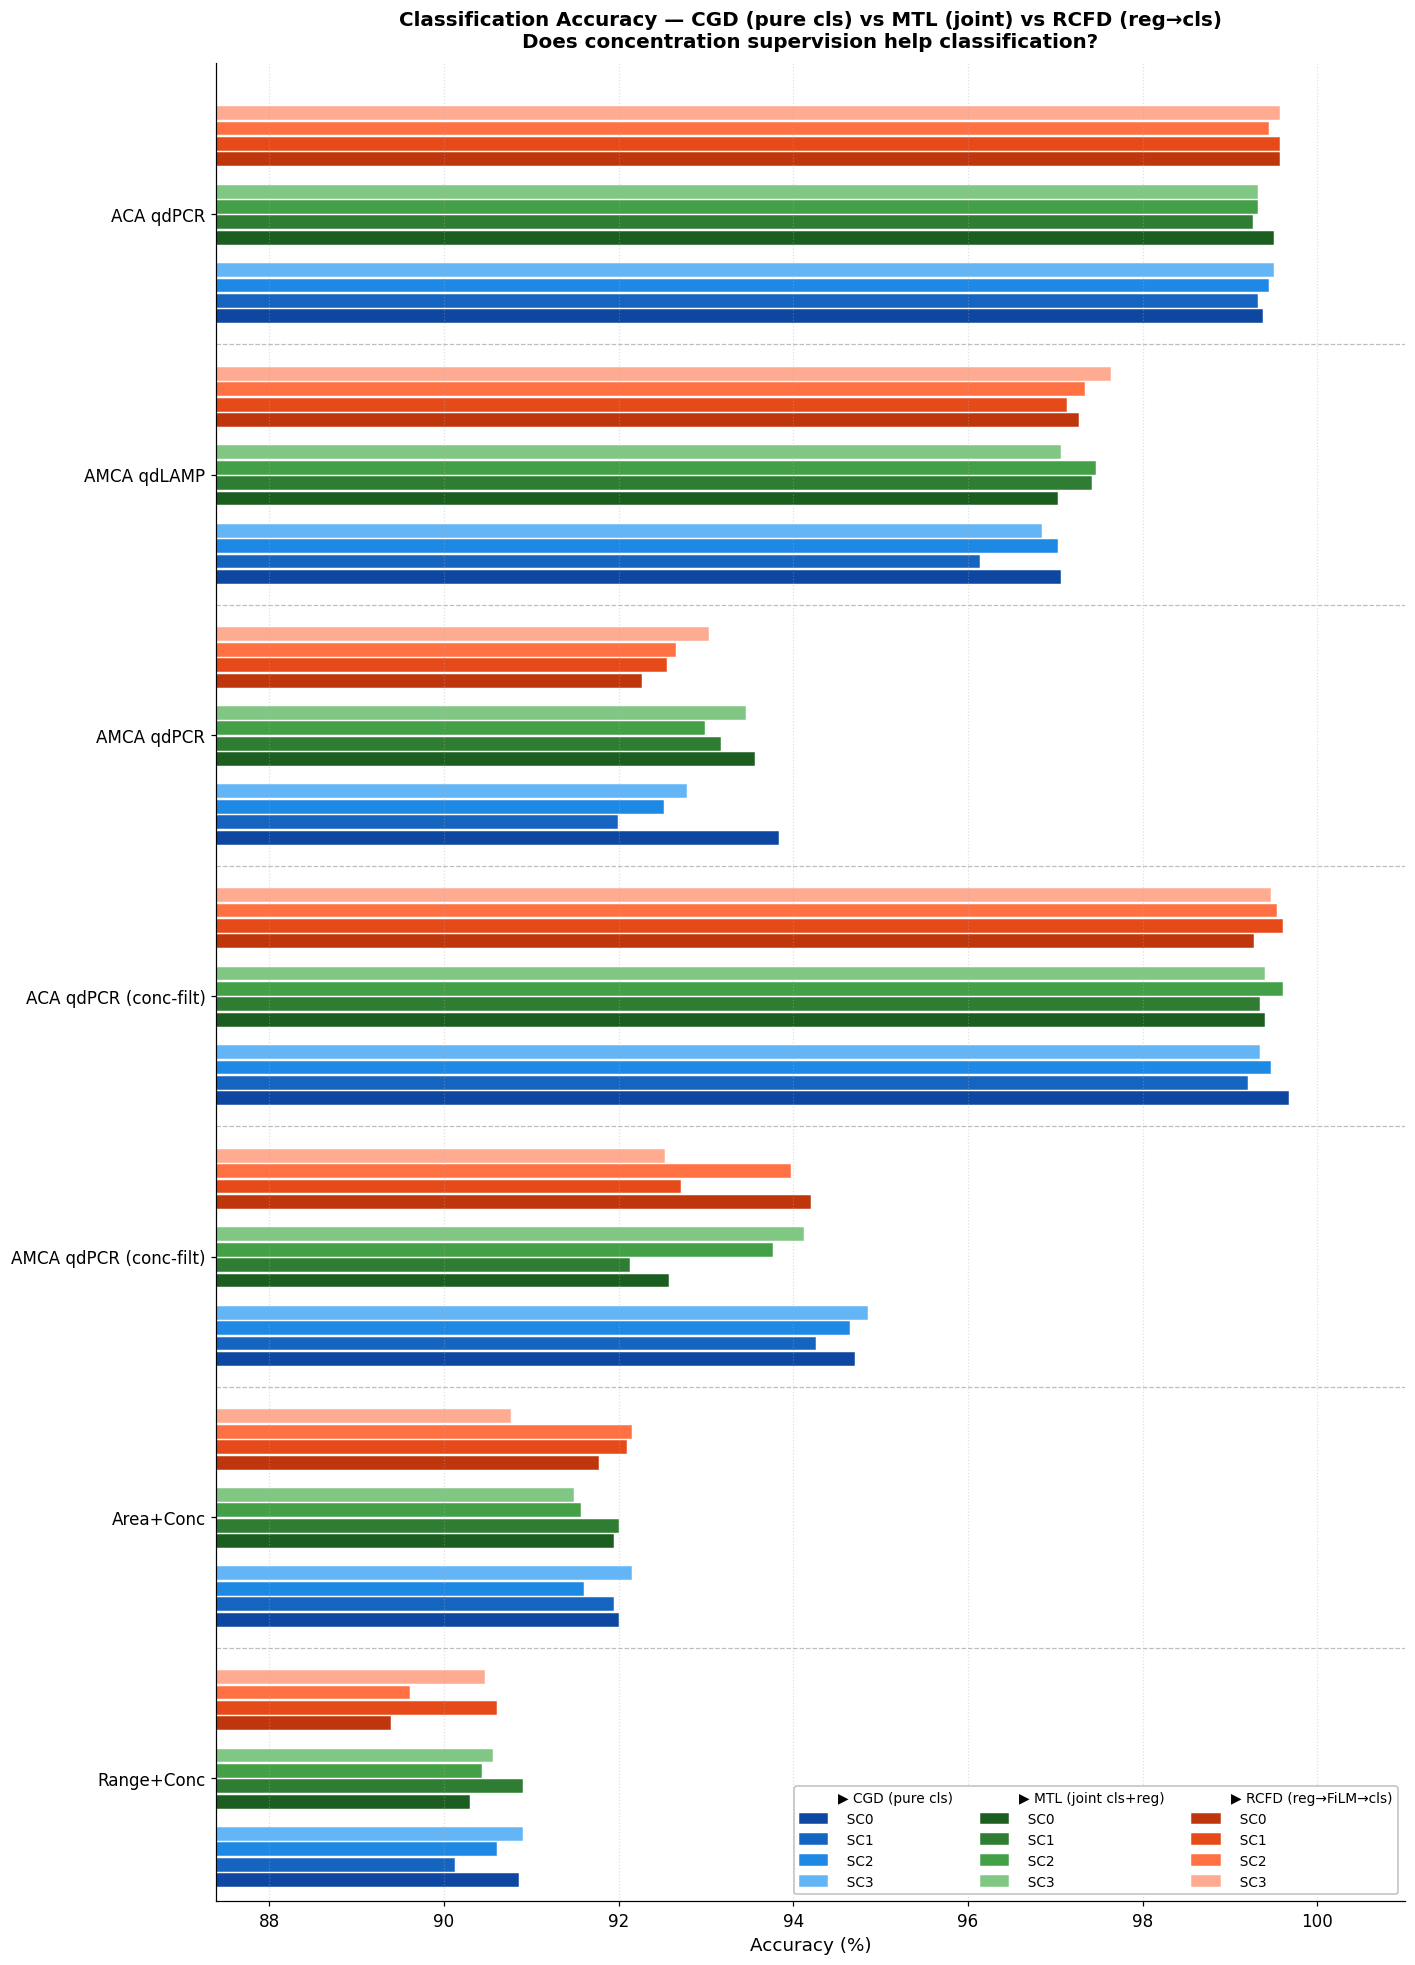

In [69]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 1 — Accuracy: CGD → MTL → RCFD  (CCFD-POC has no cls output)
# y = dataset, bars = model variants, hue = family+SC level
# ═══════════════════════════════════════════════════════════════════════════════

acc_family_order = ['CGD', 'MTL', 'RCFD']

fig, ax = plt.subplots(figsize=(13, 18))

ds_centers, y_max = draw_grouped_hbar(
    ax, cls_data, DATASETS_ORDER, DS_LABELS,
    family_order=acc_family_order,
    families=FAMILIES, fcolors=FCOLORS,
    bar_h=0.55, family_gap=0.6, ds_gap=1.5,
)

format_ds_yaxis(ax, ds_centers, DATASETS_ORDER, DS_LABELS, y_max)

# x-axis: zoom into the interesting range
all_accs = [v for d in cls_data.values() for v in d.values()]
x_min = max(50, np.nanmin(all_accs) - 2)
ax.set_xlim(x_min, 101)
ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title(
    'Classification Accuracy — CGD (pure cls) vs MTL (joint) vs RCFD (reg→cls)\n'
    'Does concentration supervision help classification?',
    fontsize=13, fontweight='bold', pad=10
)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend
legend_handles = []
for fname in acc_family_order:
    legend_handles.append(mpatches.Patch(facecolor='none', edgecolor='none',
                                          label=f'▶ {FAMILY_LABEL[fname]}'))
    for sc_idx, sc_lbl in enumerate(SC_LABELS):
        legend_handles.append(mpatches.Patch(color=FCOLORS[fname][sc_idx], label=f'  {sc_lbl}'))
ax.legend(handles=legend_handles, fontsize=9, loc='lower right',
          framealpha=0.95, edgecolor='#BDBDBD', ncol=3)

plt.tight_layout()
plt.show()

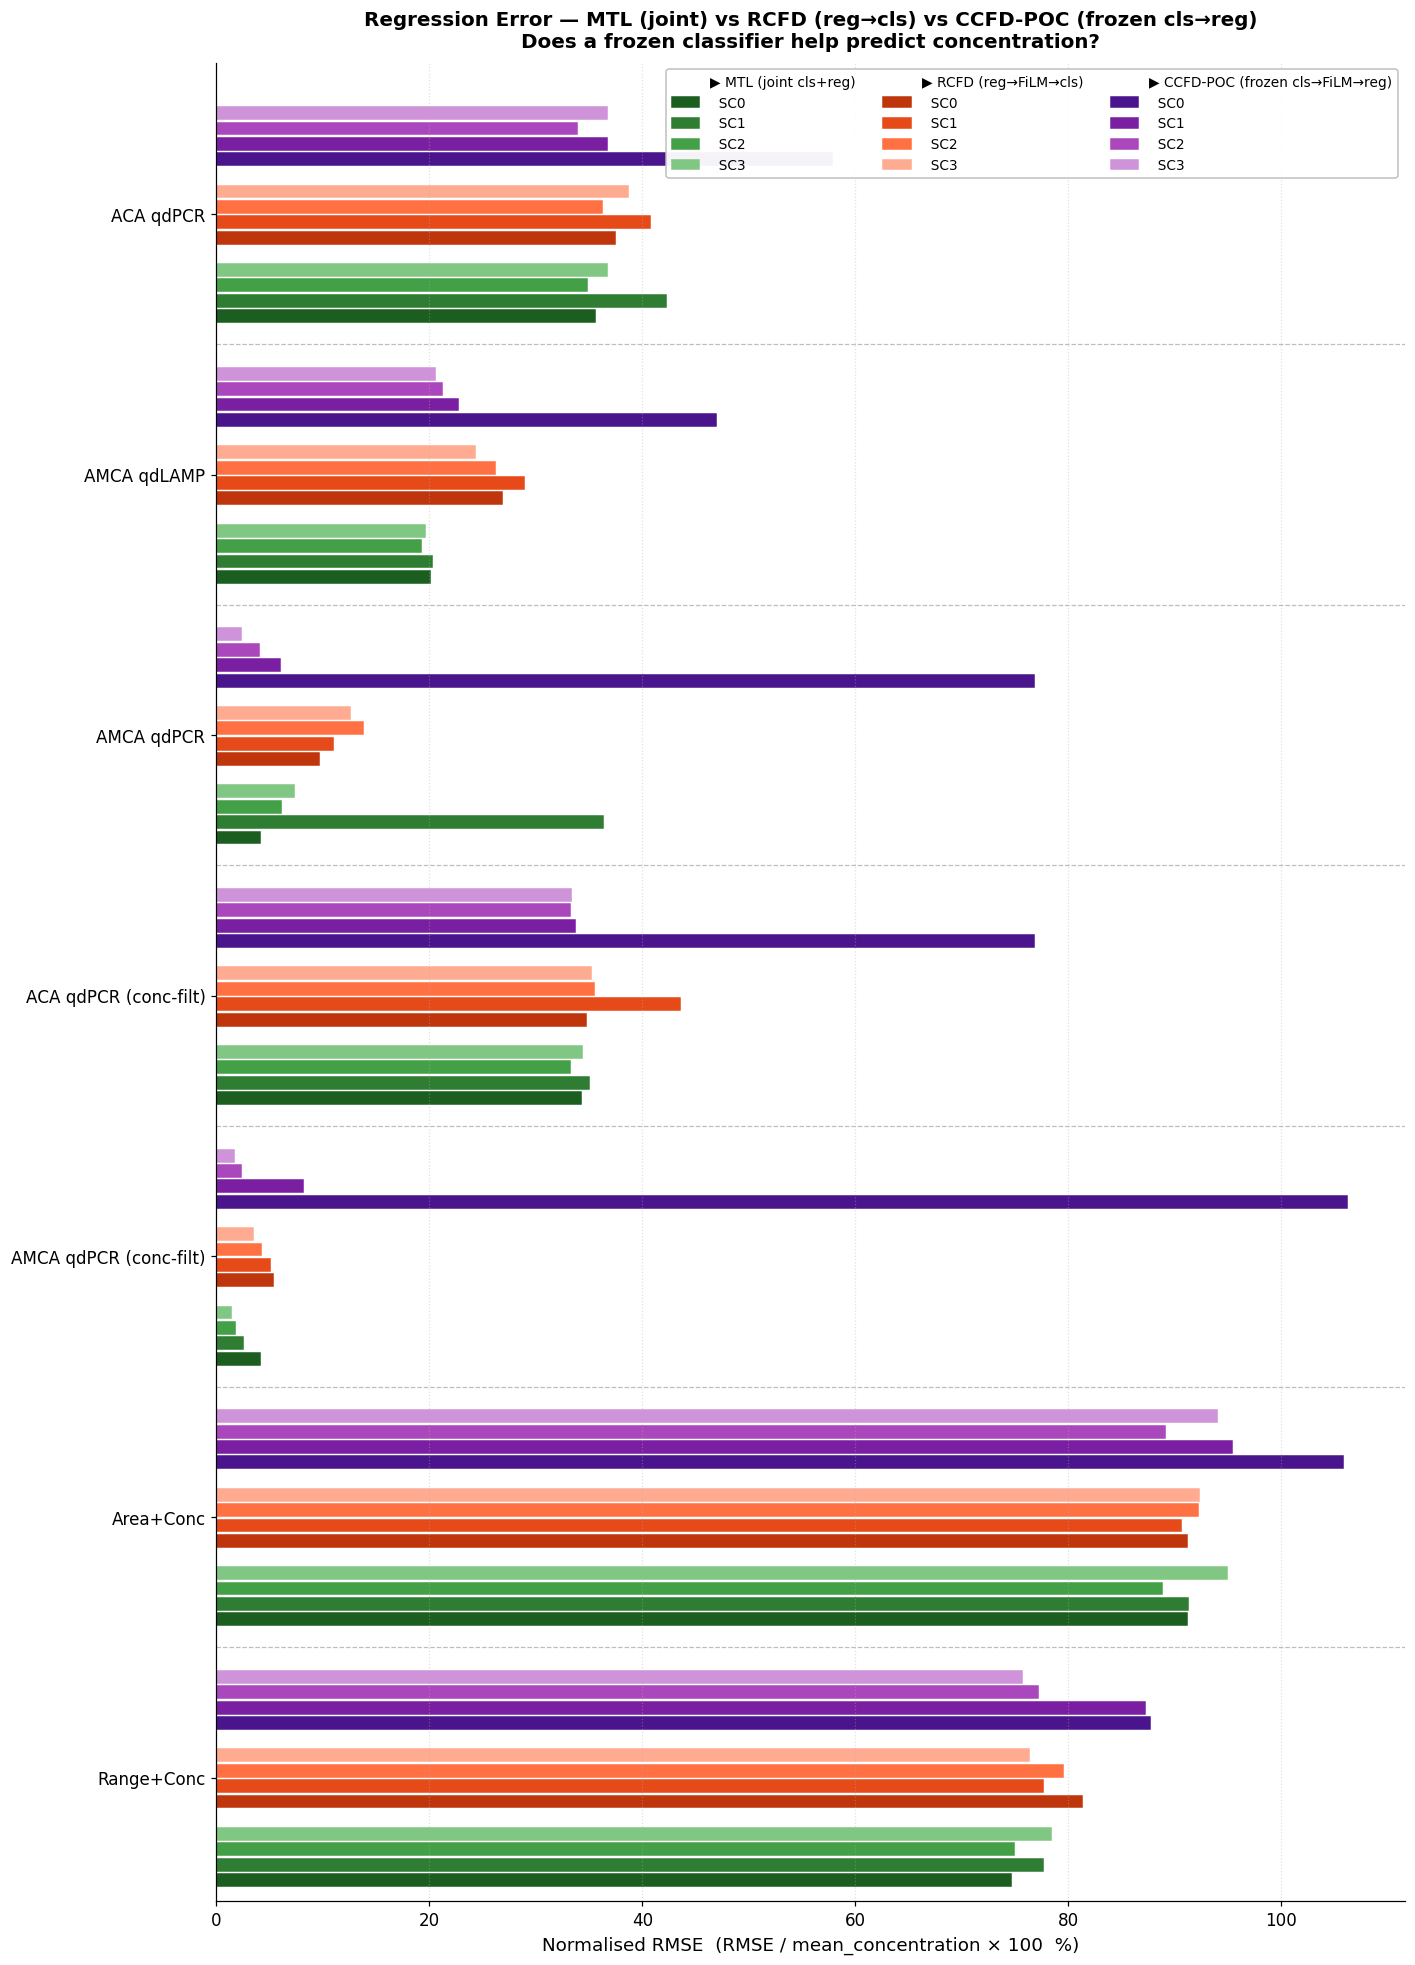

In [70]:
# ═══════════════════════════════════════════════════════════════════════════════
# Chart 2 — RMSE (%): MTL → RCFD → CCFD-POC  (CGD has no reg output)
# Normalised RMSE = (RMSE / mean_concentration) × 100  — makes datasets comparable
# y = dataset, bars = model variants, hue = family+SC level
# ═══════════════════════════════════════════════════════════════════════════════

rmse_family_order = ['MTL', 'RCFD', 'CCFD-POC']

# Build normalised-RMSE data dict
reg_pct_data = {}
for ds_id in DATASETS_ORDER:
    cmean = conc_mean.get(ds_id, np.nan)
    reg_pct_data[ds_id] = {}
    for key, rmse in reg_data.get(ds_id, {}).items():
        if not np.isnan(rmse) and cmean > 0:
            reg_pct_data[ds_id][key] = rmse / cmean * 100

fig, ax = plt.subplots(figsize=(13, 18))

ds_centers, y_max = draw_grouped_hbar(
    ax, reg_pct_data, DATASETS_ORDER, DS_LABELS,
    family_order=rmse_family_order,
    families=FAMILIES, fcolors=FCOLORS,
    bar_h=0.55, family_gap=0.6, ds_gap=1.5,
)

format_ds_yaxis(ax, ds_centers, DATASETS_ORDER, DS_LABELS, y_max)

ax.set_xlabel('Normalised RMSE  (RMSE / mean_concentration × 100  %)', fontsize=12)
ax.set_title(
    'Regression Error — MTL (joint) vs RCFD (reg→cls) vs CCFD-POC (frozen cls→reg)\n'
    'Does a frozen classifier help predict concentration?',
    fontsize=13, fontweight='bold', pad=10
)
ax.grid(axis='x', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = []
for fname in rmse_family_order:
    legend_handles.append(mpatches.Patch(facecolor='none', edgecolor='none',
                                          label=f'▶ {FAMILY_LABEL[fname]}'))
    for sc_idx, sc_lbl in enumerate(SC_LABELS):
        legend_handles.append(mpatches.Patch(color=FCOLORS[fname][sc_idx], label=f'  {sc_lbl}'))
ax.legend(handles=legend_handles, fontsize=9, loc='upper right',
          framealpha=0.95, edgecolor='#BDBDBD', ncol=3)

plt.tight_layout()
plt.show()

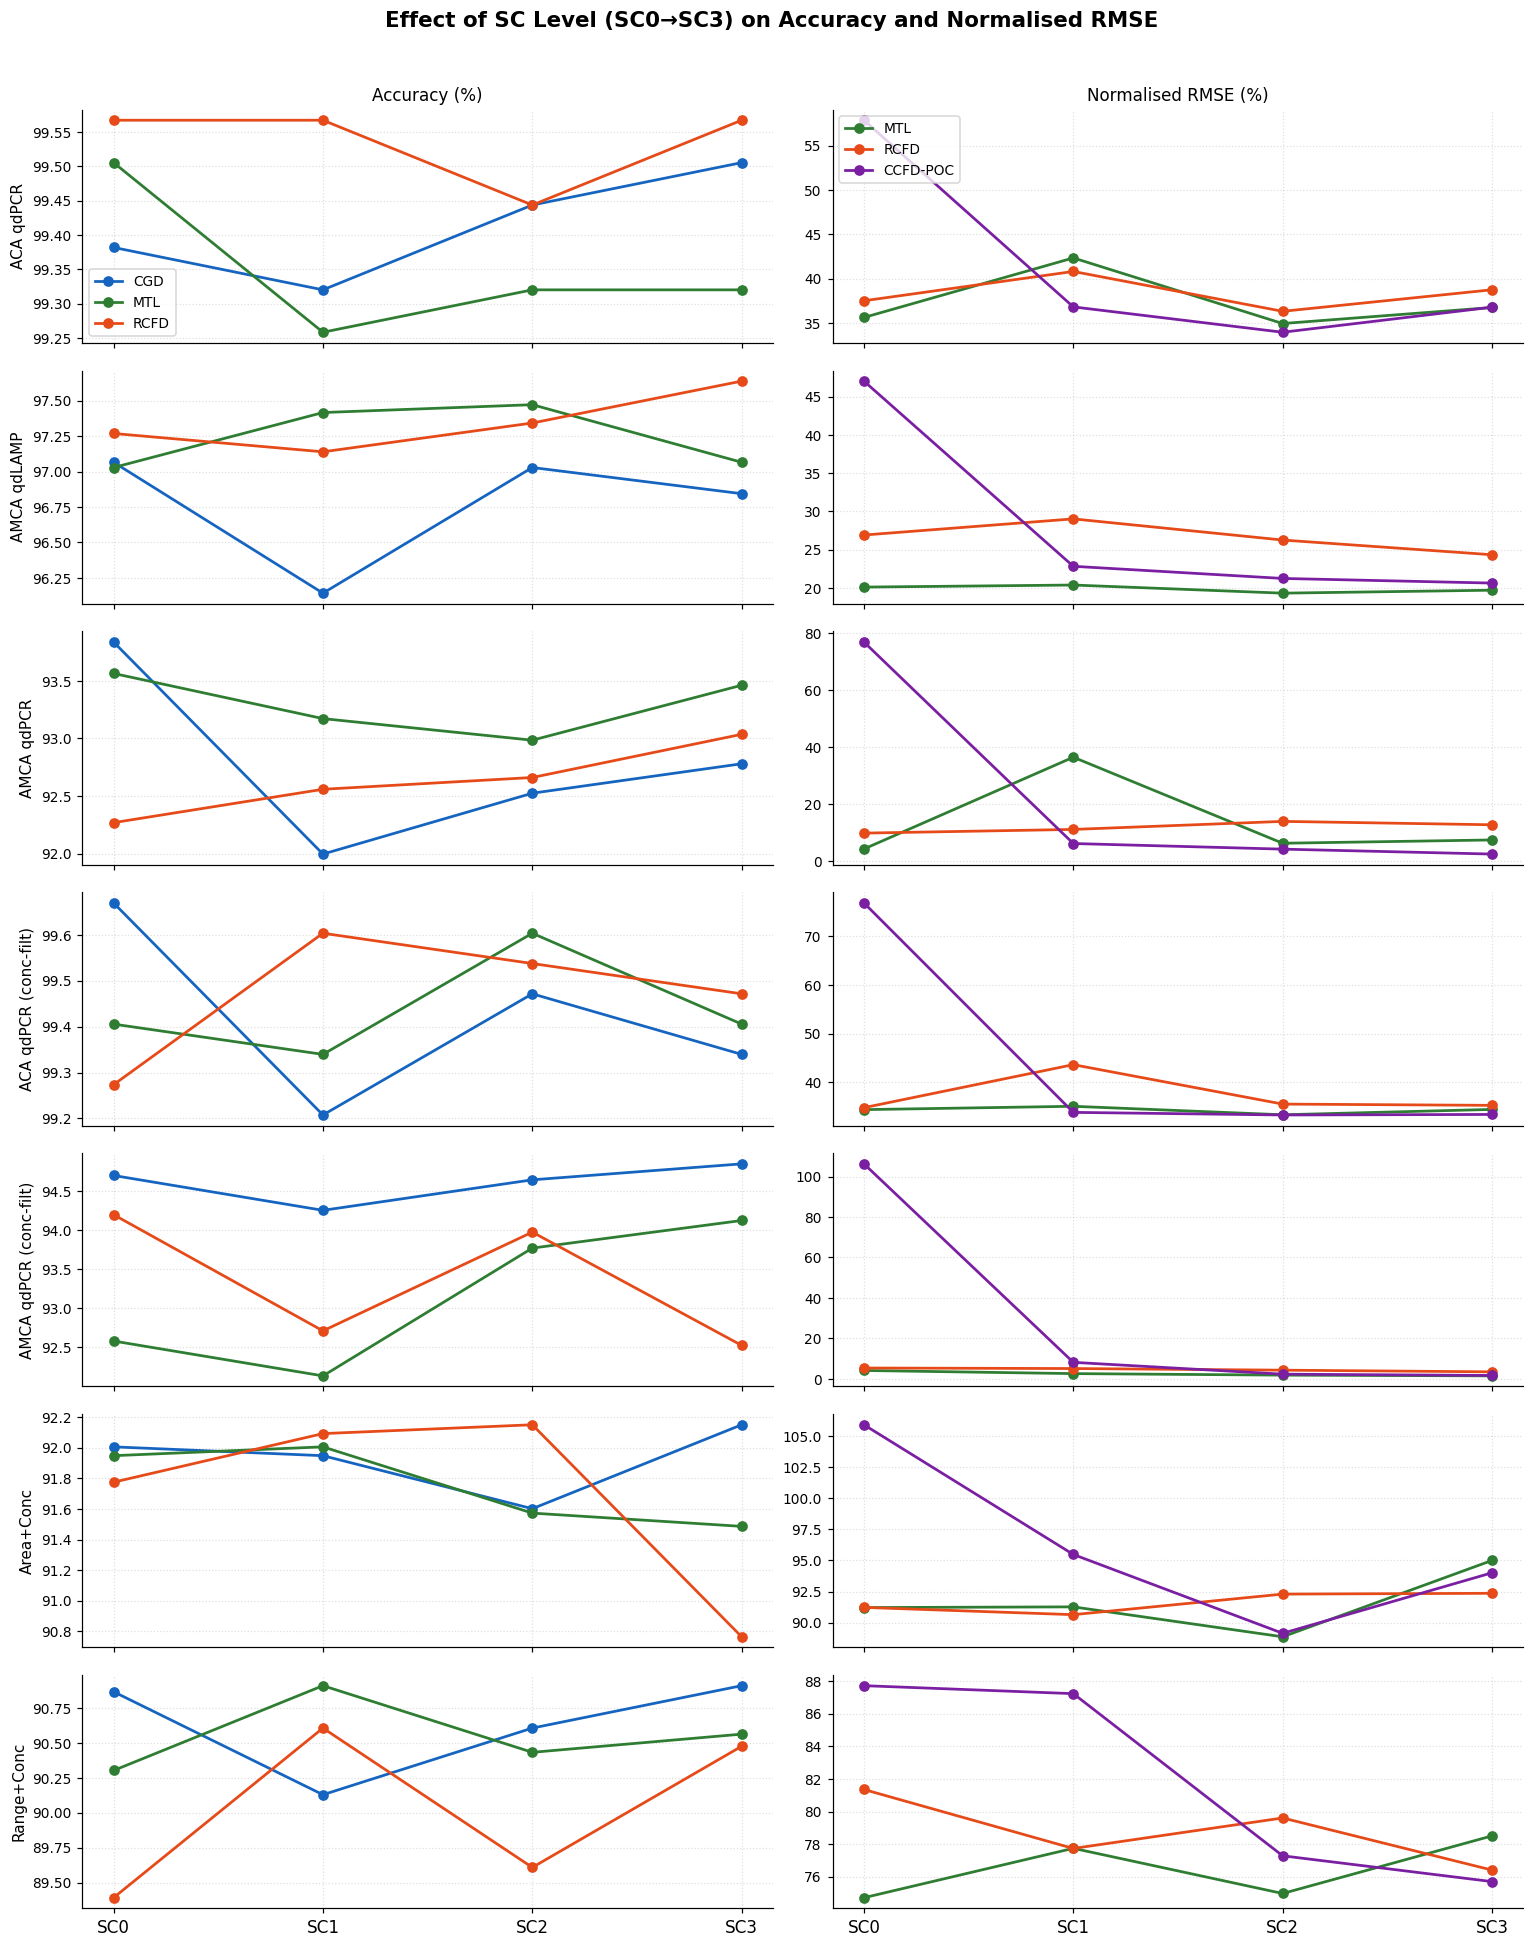

In [71]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 3 — SC-level trajectory per family
# Line plots: SC0→SC3 effect on accuracy (cls families) and RMSE (reg families)
# One subplot per dataset, two panels (cls / reg)
# Answers: "Does SupCon help — and where?"
# ═══════════════════════════════════════════════════════════════════════════════

n_ds = len(DATASETS_ORDER)
fig, axes = plt.subplots(n_ds, 2, figsize=(14, n_ds * 2.5), sharex='col')
fig.suptitle('Effect of SC Level (SC0→SC3) on Accuracy and Normalised RMSE',
             fontsize=14, fontweight='bold', y=1.01)

markers = ['o', 's', 'D', '^']  # SC0..SC3

for row, ds_id in enumerate(DATASETS_ORDER):
    ax_cls = axes[row, 0]
    ax_reg = axes[row, 1]
    ds_label = DS_LABELS[ds_id]
    cmean = conc_mean.get(ds_id, np.nan)

    # --- accuracy panel ---
    for fname in ['CGD', 'MTL', 'RCFD']:
        ys = [cls_data.get(ds_id, {}).get(k, np.nan) for k in FAMILIES[fname]]
        ax_cls.plot(SC_LABELS, ys, color=FCOLORS[fname][1], marker='o',
                    linewidth=1.8, markersize=6, label=fname)
    ax_cls.set_ylabel(ds_label, fontsize=10, labelpad=4)
    ax_cls.yaxis.set_tick_params(labelsize=9)
    ax_cls.grid(linestyle=':', alpha=0.4)
    ax_cls.spines['top'].set_visible(False)
    ax_cls.spines['right'].set_visible(False)
    if row == 0:
        ax_cls.set_title('Accuracy (%)', fontsize=11)
        ax_cls.legend(fontsize=9, loc='lower left')

    # --- RMSE panel ---
    for fname in ['MTL', 'RCFD', 'CCFD-POC']:
        ys = []
        for k in FAMILIES[fname]:
            rmse = reg_data.get(ds_id, {}).get(k, np.nan)
            ys.append(rmse / cmean * 100 if (not np.isnan(rmse) and cmean > 0) else np.nan)
        ax_reg.plot(SC_LABELS, ys, color=FCOLORS[fname][1], marker='o',
                    linewidth=1.8, markersize=6, label=fname)
    ax_reg.yaxis.set_tick_params(labelsize=9)
    ax_reg.grid(linestyle=':', alpha=0.4)
    ax_reg.spines['top'].set_visible(False)
    ax_reg.spines['right'].set_visible(False)
    if row == 0:
        ax_reg.set_title('Normalised RMSE (%)', fontsize=11)
        ax_reg.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.show()

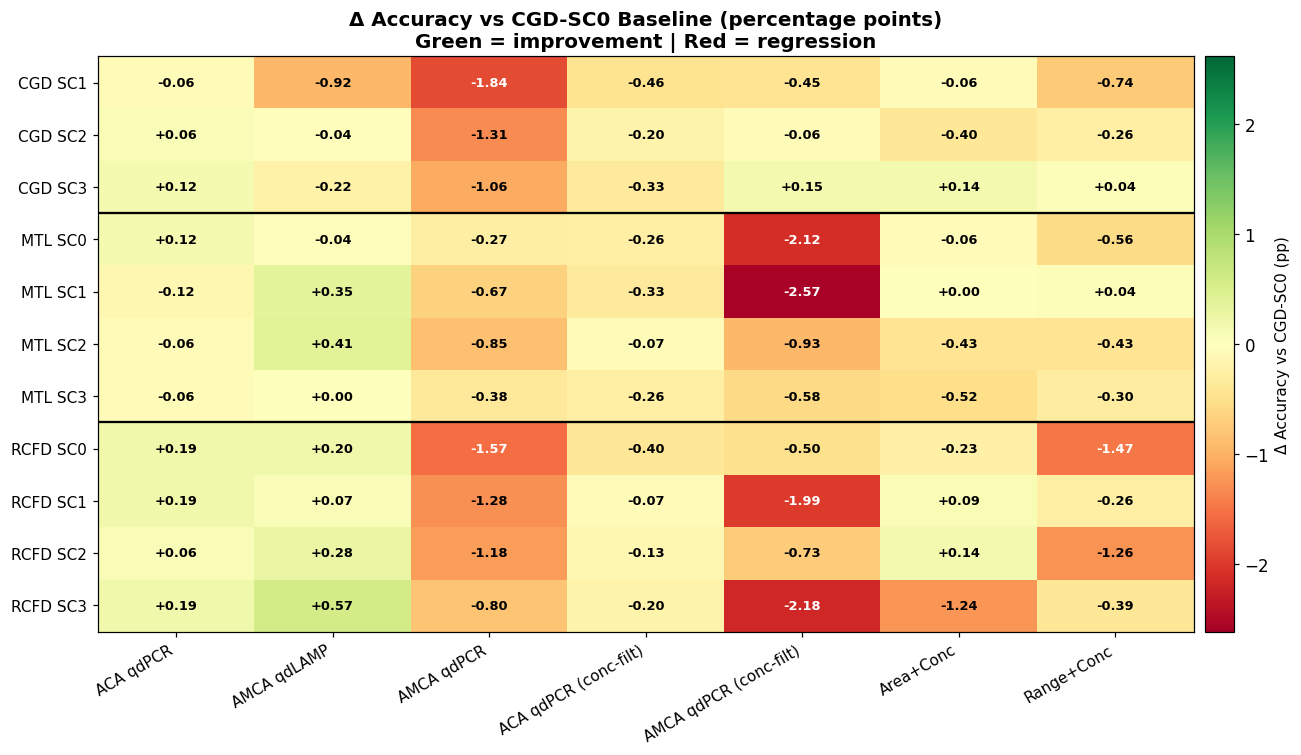

In [72]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 4 — Δ Accuracy from CGD-SC0 baseline (heatmap)
# Rows = model (MTL/RCFD SC0-3), Cols = dataset
# Cell = accuracy(model) - accuracy(CGD-SC0)   → positive = improvement
# Answers: "Does concentration supervision (any form) improve classification?"
# ═══════════════════════════════════════════════════════════════════════════════

baseline_key = 'cgd_rc_poc'  # CGD-SC0

# models to compare against baseline
compare_keys = [
    ('CGD', 'cgd_rc_poc_sc1'), ('CGD', 'cgd_rc_poc_sc2'), ('CGD', 'cgd_rc_poc_sc3'),
    ('MTL', 'mtl_cgd_rc_poc'), ('MTL', 'mtl_cgd_rc_poc_sc1'), ('MTL', 'mtl_cgd_rc_poc_sc2'), ('MTL', 'mtl_cgd_rc_poc_sc3'),
    ('RCFD', 'gru_rcfd_cgd_rc_poc'), ('RCFD', 'gru_rcfd_cgd_rc_poc_sc1'), ('RCFD', 'gru_rcfd_cgd_rc_poc_sc2'), ('RCFD', 'gru_rcfd_cgd_rc_poc_sc3'),
]

row_labels = [
    'CGD SC1', 'CGD SC2', 'CGD SC3',
    'MTL SC0', 'MTL SC1', 'MTL SC2', 'MTL SC3',
    'RCFD SC0', 'RCFD SC1', 'RCFD SC2', 'RCFD SC3',
]

col_labels = [DS_LABELS[d] for d in DATASETS_ORDER]

delta_matrix = np.full((len(compare_keys), len(DATASETS_ORDER)), np.nan)
for col_idx, ds_id in enumerate(DATASETS_ORDER):
    baseline = cls_data.get(ds_id, {}).get(baseline_key, np.nan)
    for row_idx, (_, key) in enumerate(compare_keys):
        val = cls_data.get(ds_id, {}).get(key, np.nan)
        delta_matrix[row_idx, col_idx] = val - baseline

vmax = np.nanmax(np.abs(delta_matrix)) + 0.05

fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(delta_matrix, cmap='RdYlGn', aspect='auto',
               vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=10)
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=10)

# Annotate cells
for i in range(len(compare_keys)):
    for j in range(len(DATASETS_ORDER)):
        v = delta_matrix[i, j]
        if not np.isnan(v):
            txt = f'{v:+.2f}'
            c = 'white' if abs(v) > vmax * 0.55 else 'black'
            ax.text(j, i, txt, ha='center', va='center', fontsize=8.5,
                    color=c, fontweight='bold')

# Group separators
for sep in [2.5, 6.5]:
    ax.axhline(sep, color='black', linewidth=1.5)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.01)
cbar.set_label('Δ Accuracy vs CGD-SC0 (pp)', fontsize=10)

ax.set_title(
    'Δ Accuracy vs CGD-SC0 Baseline (percentage points)\n'
    'Green = improvement | Red = regression',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

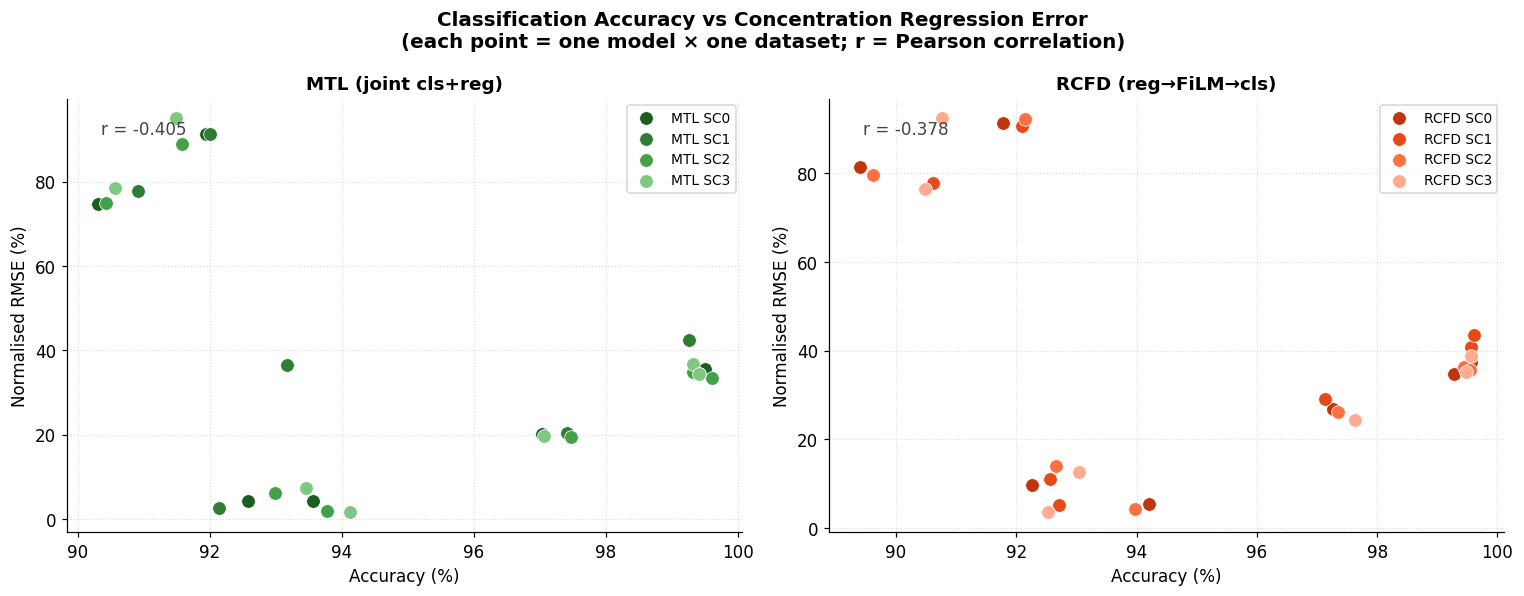

In [73]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 5 — Classification accuracy vs Regression error (scatter)
# For models with BOTH cls and reg outputs: MTL, RCFD
# Each point = (accuracy, normalised_RMSE) for one model × one dataset
# Answers: "Is there a tradeoff between cls and reg performance?"
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax_idx, (fname, family_keys) in enumerate([('MTL', MTL_KEYS), ('RCFD', RCFD_KEYS)]):
    ax = axes[ax_idx]
    for sc_idx, key in enumerate(family_keys):
        xs, ys = [], []
        for ds_id in DATASETS_ORDER:
            acc  = cls_data.get(ds_id, {}).get(key, np.nan)
            rmse = reg_data.get(ds_id, {}).get(key, np.nan)
            cmean = conc_mean.get(ds_id, np.nan)
            if not any(np.isnan([acc, rmse, cmean])) and cmean > 0:
                xs.append(acc)
                ys.append(rmse / cmean * 100)
        ax.scatter(xs, ys, color=FCOLORS[fname][sc_idx], s=80,
                   label=f'{fname} {SC_LABELS[sc_idx]}',
                   zorder=3, edgecolors='white', linewidths=0.5)

    # correlation
    all_x = [cls_data.get(d, {}).get(k, np.nan) for k in family_keys for d in DATASETS_ORDER]
    all_y_raw = [reg_data.get(d, {}).get(k, np.nan) for k in family_keys for d in DATASETS_ORDER]
    all_cm = [conc_mean.get(d, np.nan) for k in family_keys for d in DATASETS_ORDER]
    all_y = [y / cm * 100 if (not np.isnan(y) and cm > 0) else np.nan
              for y, cm in zip(all_y_raw, all_cm)]
    mask = ~np.isnan(all_x) & ~np.isnan(all_y)
    if mask.sum() > 3:
        r = np.corrcoef(np.array(all_x)[mask], np.array(all_y)[mask])[0, 1]
        ax.text(0.05, 0.95, f'r = {r:.3f}', transform=ax.transAxes,
                fontsize=11, va='top', color='#444')

    ax.set_xlabel('Accuracy (%)', fontsize=11)
    ax.set_ylabel('Normalised RMSE (%)', fontsize=11)
    ax.set_title(f'{FAMILY_LABEL[fname]}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle(
    'Classification Accuracy vs Concentration Regression Error\n'
    '(each point = one model × one dataset; r = Pearson correlation)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

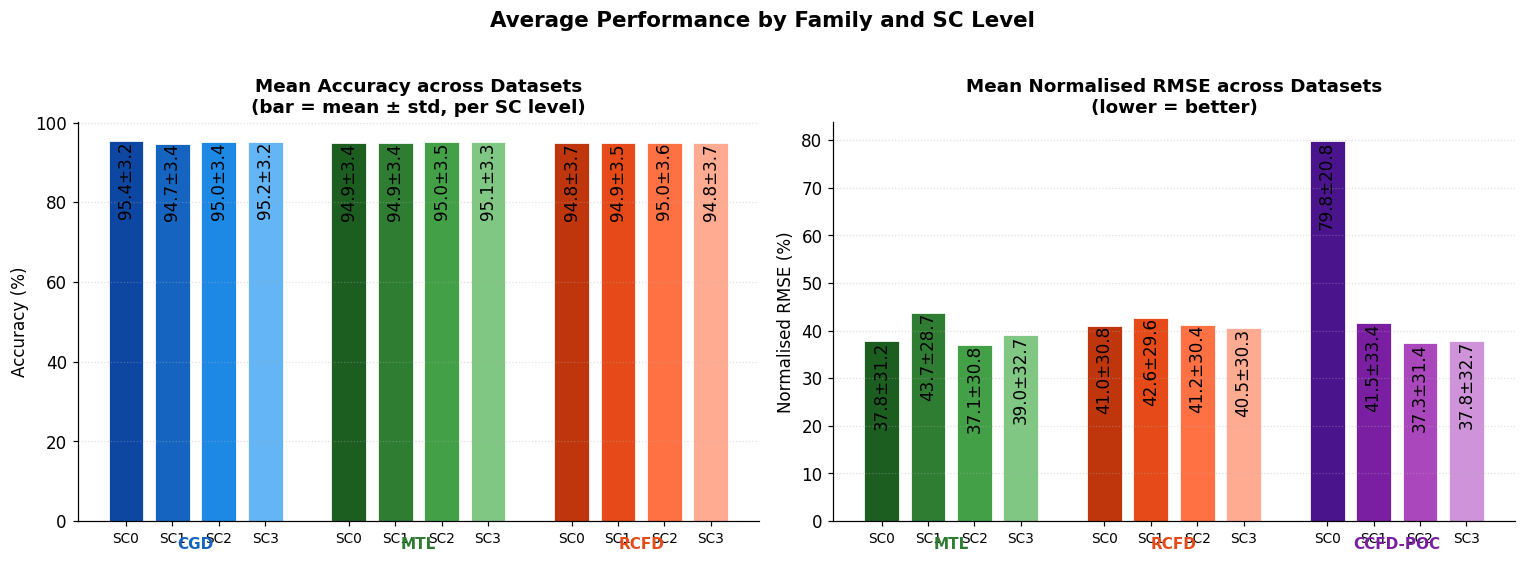

In [74]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 6 — Best-per-family summary: mean accuracy and mean RMSE across datasets
# Shows: which family wins on classification? Which wins on regression?
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Per-family, per-SC: mean across datasets
for ax, metric, data_src, family_order, ylabel in [
    (axes[0], 'accuracy', cls_data, ['CGD', 'MTL', 'RCFD'], 'Accuracy (%)'),
    (axes[1], 'rmse_pct', reg_pct_data, ['MTL', 'RCFD', 'CCFD-POC'], 'Normalised RMSE (%)'),
]:
    x_pos = 0
    xticks, xlabels = [], []

    for fname in family_order:
        for sc_idx, key in enumerate(FAMILIES[fname]):
            vals = [data_src.get(d, {}).get(key, np.nan) for d in DATASETS_ORDER]
            vals = [v for v in vals if not np.isnan(v)]
            if not vals:
                x_pos += 1; continue
            mean_v = np.mean(vals)
            std_v  = np.std(vals)
            bar = ax.bar(x_pos, mean_v, color=FCOLORS[fname][sc_idx],
                         width=0.75, edgecolor='white', linewidth=0.5)
            # ax.errorbar(x_pos, mean_v, yerr=std_v, fmt='none',
            #             color='#333', capsize=4, linewidth=1.5)
            ax.text(x_pos, mean_v, f'{mean_v:.1f}±{std_v:.1f}',
                    ha='center', va='top', fontsize=11, rotation=90,
                    color='black')
            xticks.append(x_pos)
            xlabels.append(SC_LABELS[sc_idx])
            x_pos += 1
        x_pos += 0.8  # gap between families

    ax.set_xticks(xticks)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Family labels below x-axis
    x0 = 0
    for fname in family_order:
        cx = x0 + 1.5  # centre of the 4 SC bars
        ax.text(cx, ax.get_ylim()[0] - (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.07,
                fname, ha='center', fontsize=10,
                color=FCOLORS[fname][1], fontweight='bold')
        x0 += 4.8

axes[0].set_title('Mean Accuracy across Datasets\n(bar = mean ± std, per SC level)',
                   fontsize=12, fontweight='bold')
axes[1].set_title('Mean Normalised RMSE across Datasets\n(lower = better)',
                   fontsize=12, fontweight='bold')

fig.suptitle('Average Performance by Family and SC Level',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

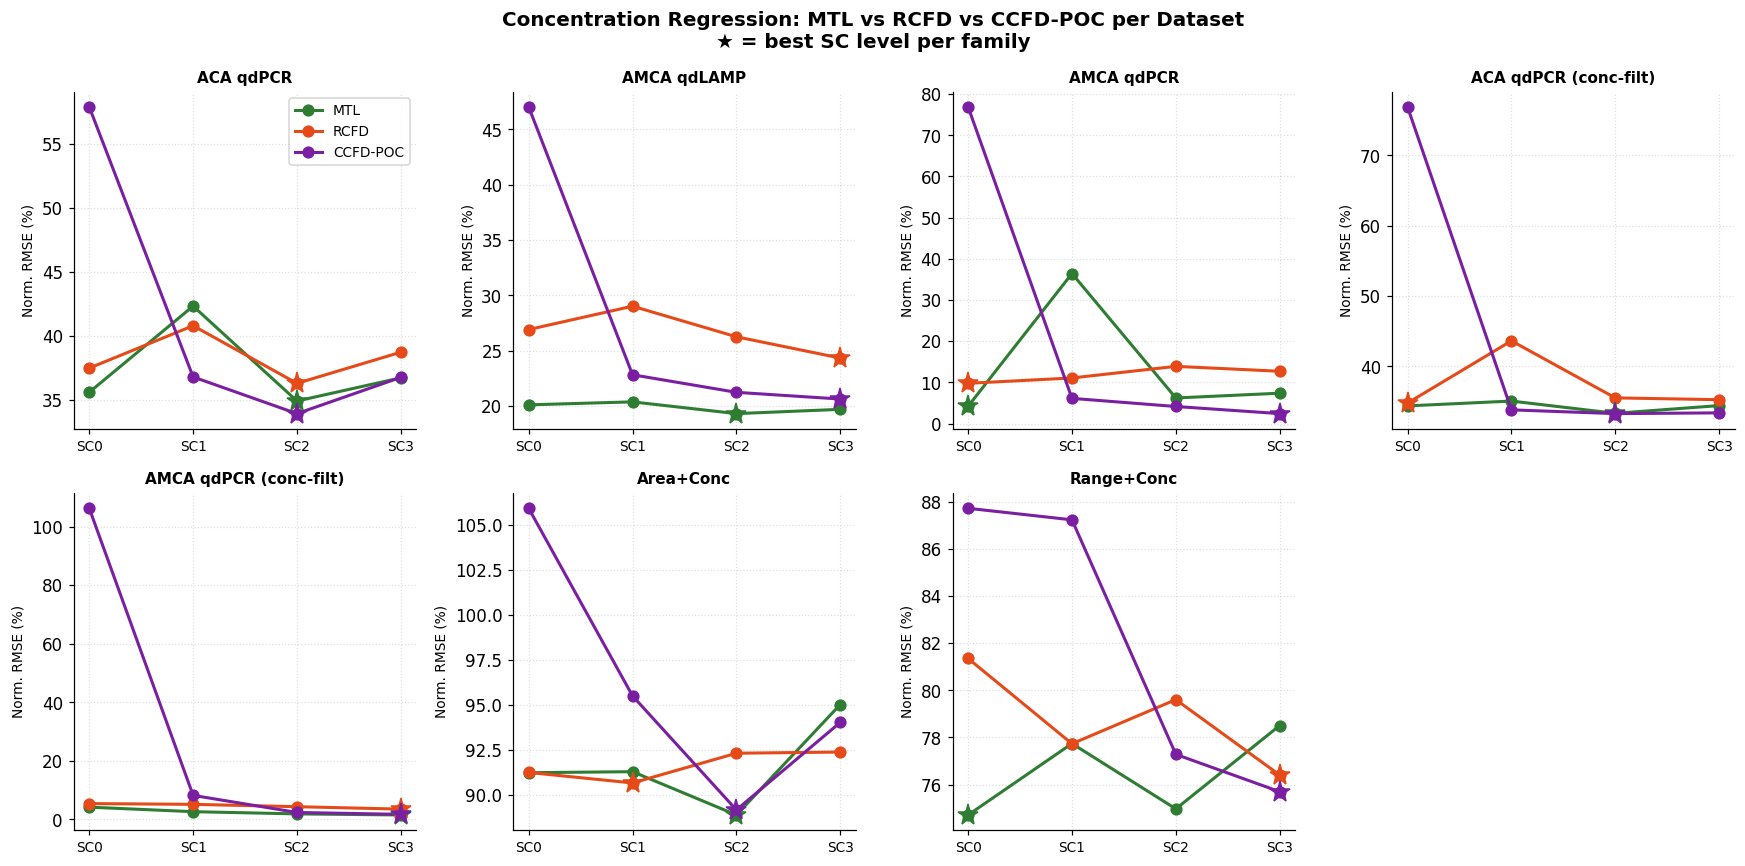

In [75]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 7 — Head-to-head: CCFD-POC vs MTL vs RCFD regression, by dataset
# For each dataset: which model predicts concentration best?
# Also shows what the best classification model's reg RMSE is (MTL/RCFD)
# Answers: "Does the frozen classifier best help regression (CCFD-POC)?"
# ═══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 4, figsize=(16, 8), sharey=False)
axes = axes.flatten()

for idx, ds_id in enumerate(DATASETS_ORDER):
    ax = axes[idx]
    ds_label = DS_LABELS[ds_id]
    cmean = conc_mean.get(ds_id, np.nan)

    for fname in ['MTL', 'RCFD', 'CCFD-POC']:
        xs = list(range(4))
        ys = []
        for key in FAMILIES[fname]:
            rmse = reg_data.get(ds_id, {}).get(key, np.nan)
            ys.append(rmse / cmean * 100 if (not np.isnan(rmse) and cmean > 0) else np.nan)
        ax.plot(xs, ys, color=FCOLORS[fname][1], marker='o',
                linewidth=2, markersize=7, label=fname)
        # highlight best SC
        best_idx = int(np.nanargmin(ys)) if not all(np.isnan(ys)) else None
        if best_idx is not None:
            ax.plot(best_idx, ys[best_idx], '*', color=FCOLORS[fname][1],
                    markersize=14, zorder=5)

    ax.set_xticks([0, 1, 2, 3])
    ax.set_xticklabels(SC_LABELS, fontsize=9)
    ax.set_title(ds_label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Norm. RMSE (%)', fontsize=9)
    ax.grid(linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if idx == 0:
        ax.legend(fontsize=9, loc='upper right')

# Hide unused subplot
axes[-1].set_visible(False)

fig.suptitle(
    'Concentration Regression: MTL vs RCFD vs CCFD-POC per Dataset\n'
    '★ = best SC level per family',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

In [76]:
# ═══════════════════════════════════════════════════════════════════════════════
# Summary table — best model per family per dataset
# ═══════════════════════════════════════════════════════════════════════════════

rows = []
for ds_id in DATASETS_ORDER:
    ds_label = DS_LABELS[ds_id]
    cmean = conc_mean.get(ds_id, np.nan)
    row = {'Dataset': ds_label}

    # Best accuracy per cls family
    for fname in ['CGD', 'MTL', 'RCFD']:
        vals = {k: cls_data.get(ds_id, {}).get(k, np.nan) for k in FAMILIES[fname]}
        best_k = max(vals, key=lambda k: vals[k] if not np.isnan(vals[k]) else -np.inf)
        best_v = vals[best_k]
        sc_lbl = SC_LABELS[FAMILIES[fname].index(best_k)]
        row[f'{fname} best acc'] = f'{best_v:.2f}% ({sc_lbl})' if not np.isnan(best_v) else 'N/A'

    # Best RMSE per reg family
    for fname in ['MTL', 'RCFD', 'CCFD-POC']:
        vals = {k: reg_data.get(ds_id, {}).get(k, np.nan) for k in FAMILIES[fname]}
        best_k = min(vals, key=lambda k: vals[k] if not np.isnan(vals[k]) else np.inf)
        best_v = vals[best_k]
        sc_lbl = SC_LABELS[FAMILIES[fname].index(best_k)]
        pct = best_v / cmean * 100 if (not np.isnan(best_v) and cmean > 0) else np.nan
        row[f'{fname} best RMSE'] = f'{pct:.1f}% ({sc_lbl})' if not np.isnan(pct) else 'N/A'

    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Dataset')

print('\n=== Best model per family × dataset ===')
print(summary_df.to_string())


=== Best model per family × dataset ===
                        CGD best acc  MTL best acc RCFD best acc MTL best RMSE RCFD best RMSE CCFD-POC best RMSE
Dataset                                                                                                         
ACA qdPCR               99.51% (SC3)  99.51% (SC0)  99.57% (SC0)   34.9% (SC2)    36.3% (SC2)        33.9% (SC2)
AMCA qdLAMP             97.07% (SC0)  97.47% (SC2)  97.64% (SC3)   19.3% (SC2)    24.3% (SC3)        20.6% (SC3)
AMCA qdPCR              93.84% (SC0)  93.57% (SC0)  93.04% (SC3)    4.2% (SC0)     9.8% (SC0)         2.4% (SC3)
ACA qdPCR (conc-filt)   99.67% (SC0)  99.60% (SC2)  99.60% (SC1)   33.3% (SC2)    34.8% (SC0)        33.3% (SC2)
AMCA qdPCR (conc-filt)  94.85% (SC3)  94.13% (SC3)  94.20% (SC0)    1.5% (SC3)     3.5% (SC3)         1.7% (SC3)
Area+Conc               92.15% (SC3)  92.01% (SC1)  92.15% (SC2)   88.9% (SC2)    90.6% (SC1)        89.1% (SC2)
Range+Conc              90.91% (SC3)  90.91% (SC1)  90.

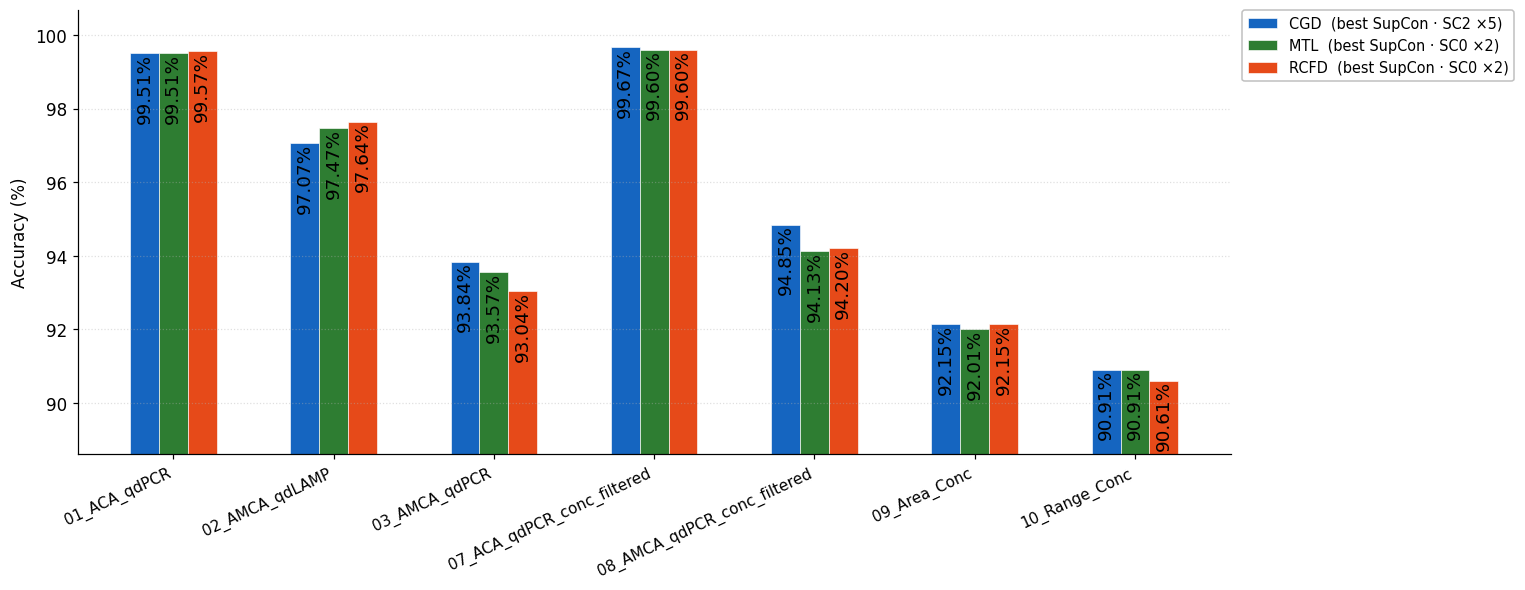

In [103]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 8 — Head-to-head accuracy: CGD-SC0 vs best CGD vs best MTL vs best RCFD
# ═══════════════════════════════════════════════════════════════════════════════

def _best_sc_cls(family_keys):
    """Which SC won most often (cls, higher=better)?"""
    counts = [0] * 4
    for ds in DATASETS_ORDER:
        vals = [cls_data.get(ds, {}).get(k, -np.inf) for k in family_keys]
        counts[int(np.argmax(vals))] += 1
    idx = int(np.argmax(counts))
    return f'SC{idx} ×{counts[idx]}'

cgd_lbl  = _best_sc_cls(CLS_KEYS[1:])   # exclude SC0 (that's the baseline)
mtl_lbl  = _best_sc_cls(MTL_KEYS)
rcfd_lbl = _best_sc_cls(RCFD_KEYS)

compare_sets = [
    # ('CGD-SC0  (baseline)',
    #  lambda ds: cls_data.get(ds, {}).get('cgd_rc_poc', np.nan), '#9E9E9E'),

    (f'CGD  (best SupCon · {cgd_lbl})',
    # (f'ST',
     lambda ds: max([cls_data.get(ds, {}).get(k, -np.inf) for k in CLS_KEYS]),
     FCOLORS['CGD'][1]),

    (f'MTL  (best SupCon · {mtl_lbl})',
    # (f'MTL',
     lambda ds: max([cls_data.get(ds, {}).get(k, -np.inf) for k in MTL_KEYS]),
     FCOLORS['MTL'][1]),

    (f'RCFD  (best SupCon · {rcfd_lbl})',
    # (f'RCFD',
     lambda ds: max([cls_data.get(ds, {}).get(k, -np.inf) for k in RCFD_KEYS]),
     FCOLORS['RCFD'][1]),
]

n_models = len(compare_sets)
n_ds = len(DATASETS_ORDER)
bar_w = 0.18
x = np.arange(n_ds)

fig, ax = plt.subplots(figsize=(14, 5.5))

for m_idx, (label, getter, color) in enumerate(compare_sets):
    vals = [getter(ds) for ds in DATASETS_ORDER]
    vals = [v if v != -np.inf else np.nan for v in vals]
    offset = (m_idx - n_models / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, vals, width=bar_w, color=color, label=label,
                  edgecolor='white', linewidth=0.4)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{v:.2f}%', ha='center', va='top', fontsize=12,
                    rotation=90, color='black')

ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[d] for d in DATASETS_ORDER], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('Accuracy (%)', fontsize=11)
# ax.set_title(
#     'Classification: CGD-SC0 Baseline vs Best MTL vs Best RCFD\n'
#     'Does concentration supervision improve classification?',
#     fontsize=13, fontweight='bold'
# )

all_vals = [getter(ds) for _, getter, _ in compare_sets for ds in DATASETS_ORDER
            if not np.isnan(getter(ds)) and getter(ds) != -np.inf]
ax.set_ylim(max(50, min(all_vals) - 2), max(all_vals) + 1)

ax.legend(fontsize=9.5, loc='upper left', bbox_to_anchor=(1.01, 1),
          borderaxespad=0, framealpha=0.95, edgecolor='#BDBDBD')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


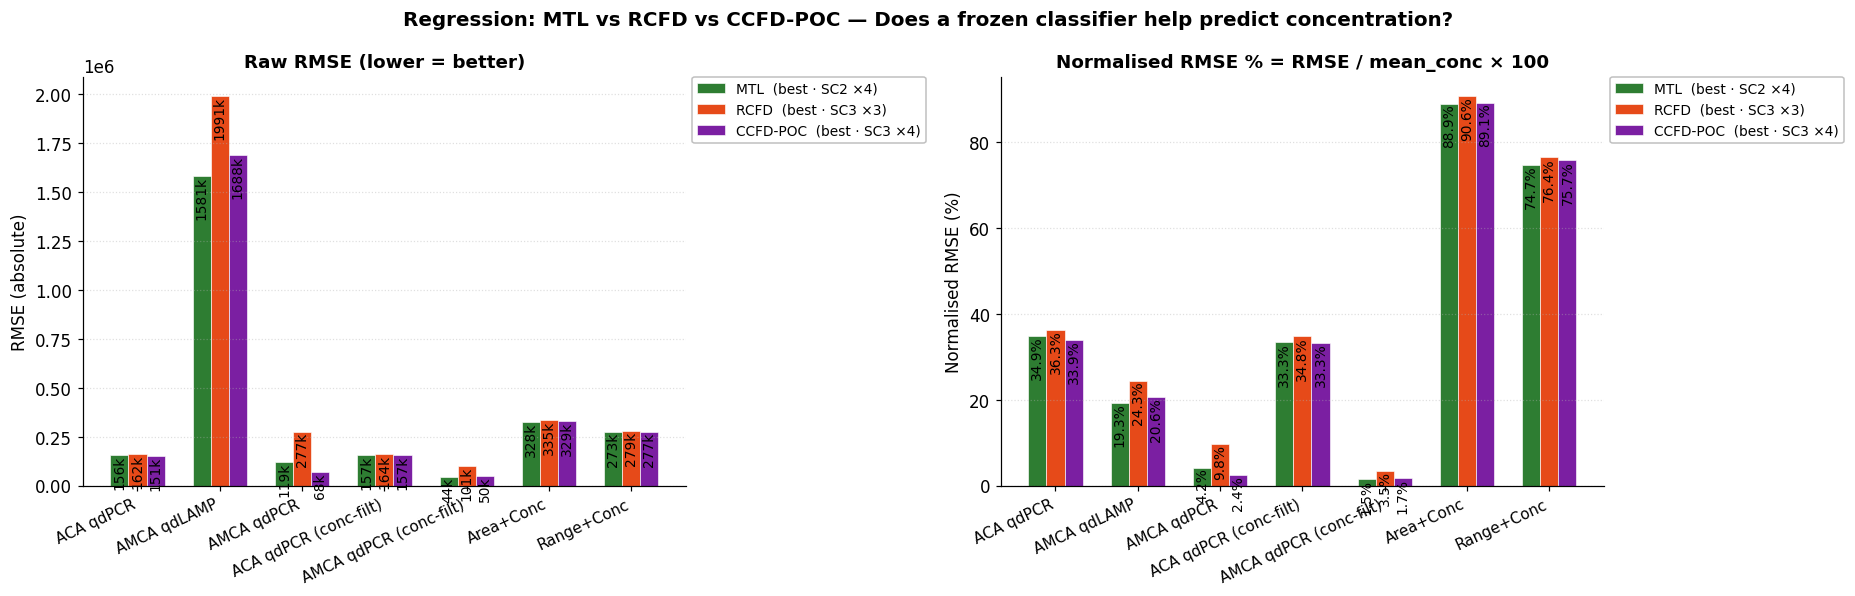

In [78]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 9 — Head-to-head regression: best MTL vs best RCFD vs best CCFD-POC
# Left: raw RMSE (absolute units) · Right: normalised RMSE % (÷ mean_concentration)
# ═══════════════════════════════════════════════════════════════════════════════

def _best_sc_reg(family_keys):
    """Which SC won most often (reg, lower=better)?"""
    counts = [0] * 4
    for ds in DATASETS_ORDER:
        vals = [reg_data.get(ds, {}).get(k, np.inf) for k in family_keys]
        counts[int(np.argmin(vals))] += 1
    idx = int(np.argmax(counts))
    return f'SC{idx} ×{counts[idx]}'

mtl_reg_lbl  = _best_sc_reg(MTL_KEYS)
rcfd_reg_lbl = _best_sc_reg(RCFD_KEYS)
ccfd_reg_lbl = _best_sc_reg(CCFD_KEYS)

compare_reg = [
    (f'MTL  (best · {mtl_reg_lbl})',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in MTL_KEYS]),
     FCOLORS['MTL'][1]),
    (f'RCFD  (best · {rcfd_reg_lbl})',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in RCFD_KEYS]),
     FCOLORS['RCFD'][1]),
    (f'CCFD-POC  (best · {ccfd_reg_lbl})',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in CCFD_KEYS]),
     FCOLORS['CCFD-POC'][1]),
]

n_models = len(compare_reg)
n_ds = len(DATASETS_ORDER)
bar_w = 0.22
x = np.arange(n_ds)

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

for ax, use_norm, ylabel, fmt_fn in [
    (axes[0], False, 'RMSE (absolute)',           lambda v: f'{v/1e3:.0f}k'),
    (axes[1], True,  'Normalised RMSE (%)',        lambda v: f'{v:.1f}%'),
]:
    for m_idx, (label, getter, color) in enumerate(compare_reg):
        raw_vals = [getter(ds) for ds in DATASETS_ORDER]
        raw_vals = [v if v != np.inf else np.nan for v in raw_vals]

        if use_norm:
            disp_vals = [v / conc_mean[ds] * 100 if (not np.isnan(v) and conc_mean.get(ds,0) > 0) else np.nan
                         for v, ds in zip(raw_vals, DATASETS_ORDER)]
            lbl_fn = lambda v: f'{v:.1f}%'
        else:
            disp_vals = raw_vals
            lbl_fn = fmt_fn

        offset = (m_idx - n_models / 2 + 0.5) * bar_w
        bars = ax.bar(x + offset, disp_vals, width=bar_w, color=color, label=label,
                      edgecolor='white', linewidth=0.4)
        for bar, v in zip(bars, disp_vals):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                        lbl_fn(v), ha='center', va='top', fontsize=9,
                        rotation=90, color='black')

    ax.set_xticks(x)
    ax.set_xticklabels([DS_LABELS[d] for d in DATASETS_ORDER], rotation=25, ha='right', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.01, 1),
              borderaxespad=0, framealpha=0.95, edgecolor='#BDBDBD')
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_title('Raw RMSE (lower = better)', fontsize=12, fontweight='bold')
axes[1].set_title('Normalised RMSE % = RMSE / mean_conc × 100', fontsize=12, fontweight='bold')

fig.suptitle(
    'Regression: MTL vs RCFD vs CCFD-POC — Does a frozen classifier help predict concentration?',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


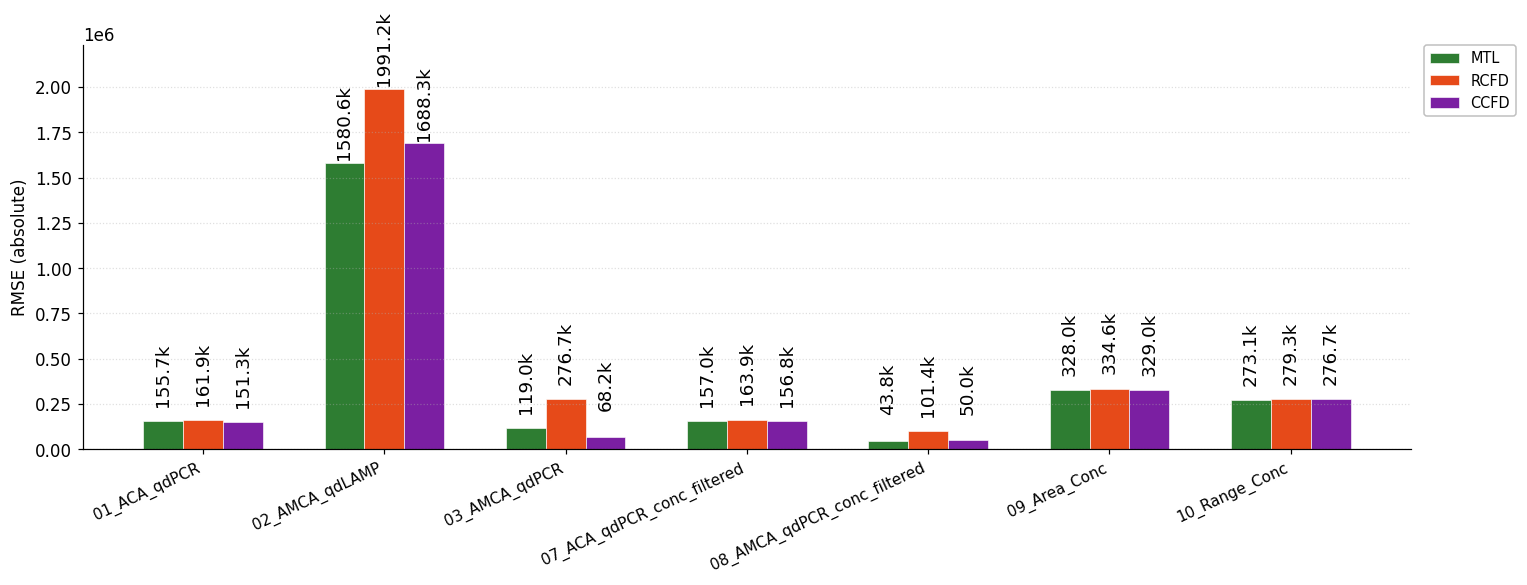

In [102]:
# ═══════════════════════════════════════════════════════════════════════════════
# Viz 10 — Head-to-head regression (raw RMSE): best MTL vs best RCFD vs best CCFD-POC
# ═══════════════════════════════════════════════════════════════════════════════

def _best_sc_reg(family_keys):
    counts = [0] * 4
    for ds in DATASETS_ORDER:
        vals = [reg_data.get(ds, {}).get(k, np.inf) for k in family_keys]
        counts[int(np.argmin(vals))] += 1
    idx = int(np.argmax(counts))
    return f'SC{idx} ×{counts[idx]}'

mtl_reg_lbl  = _best_sc_reg(MTL_KEYS)
rcfd_reg_lbl = _best_sc_reg(RCFD_KEYS)
ccfd_reg_lbl = _best_sc_reg(CCFD_KEYS)

compare_reg = [
    (f'MTL',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in MTL_KEYS]),
     FCOLORS['MTL'][1]),
    (f'RCFD',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in RCFD_KEYS]),
     FCOLORS['RCFD'][1]),
    (f'CCFD',
     lambda ds: min([reg_data.get(ds, {}).get(k, np.inf) for k in CCFD_KEYS]),
     FCOLORS['CCFD-POC'][1]),
]

n_models = len(compare_reg)
n_ds = len(DATASETS_ORDER)
bar_w = 0.22
x = np.arange(n_ds)

fig, ax = plt.subplots(figsize=(14, 5.5))

for m_idx, (label, getter, color) in enumerate(compare_reg):
    vals = [getter(ds) for ds in DATASETS_ORDER]
    vals = [v if v != np.inf else np.nan for v in vals]
    offset = (m_idx - n_models / 2 + 0.5) * bar_w
    bars = ax.bar(x + offset, vals, width=bar_w, color=color, label=label,
                  edgecolor='white', linewidth=0.4)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height()+430000,
                    f'{v/1e3:.1f}k', ha='center', va='top', fontsize=12,
                    rotation=90, color='black')

ax.set_xticks(x)
ax.set_xticklabels([DS_LABELS[d] for d in DATASETS_ORDER], rotation=25, ha='right', fontsize=10)
ax.set_ylabel('RMSE (absolute)', fontsize=11)

all_vals = [getter(ds) for _, getter, _ in compare_reg for ds in DATASETS_ORDER
            if not np.isnan(v := getter(ds)) and v != np.inf]
ax.set_ylim(0, max(all_vals) * 1.12)

ax.legend(fontsize=9.5, loc='upper left', bbox_to_anchor=(1.01, 1),
          borderaxespad=0, framealpha=0.95, edgecolor='#BDBDBD')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [79]:
raw_df.to_csv("/vol/bitbucket/gk225/all_results.csv", index=False)